In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report,accuracy_score,confusion_matrix,average_precision_score
from sklearn.model_selection import train_test_split,StratifiedKFold,RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import HistGradientBoostingClassifier,RandomForestClassifier


In [2]:
pd.set_option("display.max_columns",None)
pd.set_option("display.float_format",lambda x:f"{x:.3f}")
sns.set_theme(style="darkgrid")

In [3]:
df=pd.read_csv("creditcard.csv")

In [4]:
df.shape

(284807, 31)

In [5]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.000,-1.360,-0.073,2.536,1.378,-0.338,0.462,0.240,0.099,0.364,0.091,-0.552,-0.618,-0.991,-0.311,1.468,-0.470,0.208,0.026,0.404,0.251,-0.018,0.278,-0.110,0.067,0.129,-0.189,0.134,-0.021,149.620,0
1,0.000,1.192,0.266,0.166,0.448,0.060,-0.082,-0.079,0.085,-0.255,-0.167,1.613,1.065,0.489,-0.144,0.636,0.464,-0.115,-0.183,-0.146,-0.069,-0.226,-0.639,0.101,-0.340,0.167,0.126,-0.009,0.015,2.690,0
2,1.000,-1.358,-1.340,1.773,0.380,-0.503,1.800,0.791,0.248,-1.515,0.208,0.625,0.066,0.717,-0.166,2.346,-2.890,1.110,-0.121,-2.262,0.525,0.248,0.772,0.909,-0.689,-0.328,-0.139,-0.055,-0.060,378.660,0
3,1.000,-0.966,-0.185,1.793,-0.863,-0.010,1.247,0.238,0.377,-1.387,-0.055,-0.226,0.178,0.508,-0.288,-0.631,-1.060,-0.684,1.966,-1.233,-0.208,-0.108,0.005,-0.190,-1.176,0.647,-0.222,0.063,0.061,123.500,0
4,2.000,-1.158,0.878,1.549,0.403,-0.407,0.096,0.593,-0.271,0.818,0.753,-0.823,0.538,1.346,-1.120,0.175,-0.451,-0.237,-0.038,0.803,0.409,-0.009,0.798,-0.137,0.141,-0.206,0.502,0.219,0.215,69.990,0


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     284807 non-nu

In [7]:
df.isna().sum().sort_values

<bound method Series.sort_values of Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64>

In [8]:
for col in df.columns:
    print(df[col].value_counts().head())

Time
163152.000    36
64947.000     26
68780.000     25
3767.000      21
3770.000      20
Name: count, dtype: int64
V1
1.246    77
2.056    77
2.053    62
1.302    60
2.040    53
Name: count, dtype: int64
V2
0.167     77
-0.327    77
0.090     62
-0.607    60
-0.147    53
Name: count, dtype: int64
V3
0.488     77
-2.752    77
-1.682    62
-0.682    60
-2.956    53
Name: count, dtype: int64
V4
0.635     77
-0.842    77
0.454     62
-1.905    60
-0.578    53
Name: count, dtype: int64
V5
-0.563    77
2.463     77
0.298     62
1.327     60
2.609     53
Name: count, dtype: int64
V6
-1.011    77
3.174     77
-0.954    62
3.436     60
3.143     53
Name: count, dtype: int64
V7
0.015     77
-0.432    77
0.152     62
-1.145    60
-0.417    53
Name: count, dtype: int64
V8
-0.160    77
0.728     77
-0.207    62
0.959     60
0.784     53
Name: count, dtype: int64
V9
0.170    77
0.609    77
0.587    62
1.671    60
0.360    53
Name: count, dtype: int64
V10
-0.045    77
-0.075    77
-0.362    62
-1.02

In [9]:
duplicates=df.duplicated()
num_duplicates=duplicates.sum()
print(num_duplicates)

1081


In [10]:
print(df["Class"].value_counts())
print(df["Class"].value_counts(normalize=True)*100)
# we're not dropping the duplicates coz class 1 rows are very less so if we drop them then we may loose 

Class
0    284315
1       492
Name: count, dtype: int64
Class
0   99.827
1    0.173
Name: proportion, dtype: float64


In [11]:
n_fraud=(df["Class"]==1).sum()
non_fraud=(df["Class"]==0).sum()
print("Imbalance Ratio",round(non_fraud/max(n_fraud,1),2))

Imbalance Ratio 577.88


In [12]:
df[["Time","Amount"]].describe()

,Time,Amount
count,284807.000,284807.000
mean,94813.860,88.350
std,47488.146,250.120
min,0.000,0.000
25%,54201.500,5.600
50%,84692.000,22.000
75%,139320.500,77.165
max,172792.000,25691.160


In [13]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000,284807.000,284807.000,284807.000,284807.000,284807.000,284807.000,284807.000,284807.000,284807.000,284807.000,284807.000,284807.000,284807.000,284807.000,284807.000,284807.000,284807.000,284807.000,284807.000,284807.000,284807.000,284807.000,284807.000,284807.000,284807.000,284807.000,284807.000,284807.000,284807.000,284807.000
mean,94813.860,0.000,0.000,-0.000,0.000,0.000,0.000,-0.000,0.000,-0.000,0.000,0.000,-0.000,0.000,0.000,0.000,0.000,-0.000,0.000,0.000,0.000,0.000,-0.000,0.000,0.000,0.000,0.000,-0.000,-0.000,88.350,0.002
std,47488.146,1.959,1.651,1.516,1.416,1.380,1.332,1.237,1.194,1.099,1.089,1.021,0.999,0.995,0.959,0.915,0.876,0.849,0.838,0.814,0.771,0.735,0.726,0.624,0.606,0.521,0.482,0.404,0.330,250.120,0.042
min,0.000,-56.408,-72.716,-48.326,-5.683,-113.743,-26.161,-43.557,-73.217,-13.434,-24.588,-4.797,-18.684,-5.792,-19.214,-4.499,-14.130,-25.163,-9.499,-7.214,-54.498,-34.830,-10.933,-44.808,-2.837,-10.295,-2.605,-22.566,-15.430,0.000,0.000
25%,54201.500,-0.920,-0.599,-0.890,-0.849,-0.692,-0.768,-0.554,-0.209,-0.643,-0.535,-0.762,-0.406,-0.649,-0.426,-0.583,-0.468,-0.484,-0.499,-0.456,-0.212,-0.228,-0.542,-0.162,-0.355,-0.317,-0.327,-0.071,-0.053,5.600,0.000
50%,84692.000,0.018,0.065,0.180,-0.020,-0.054,-0.274,0.040,0.022,-0.051,-0.093,-0.033,0.140,-0.014,0.051,0.048,0.066,-0.066,-0.004,0.004,-0.062,-0.029,0.007,-0.011,0.041,0.017,-0.052,0.001,0.011,22.000,0.000
75%,139320.500,1.316,0.804,1.027,0.743,0.612,0.399,0.570,0.327,0.597,0.454,0.740,0.618,0.663,0.493,0.649,0.523,0.400,0.501,0.459,0.133,0.186,0.529,0.148,0.440,0.351,0.241,0.091,0.078,77.165,0.000
max,172792.000,2.455,22.058,9.383,16.875,34.802,73.302,120.589,20.007,15.595,23.745,12.019,7.848,7.127,10.527,8.878,17.315,9.254,5.041,5.592,39.421,27.203,10.503,22.528,4.585,7.520,3.517,31.612,33.848,25691.160,1.000


In [14]:
#here mean~0 we dont need to scale 
#usually pca is done after scaling of data
#so we dont need to scale

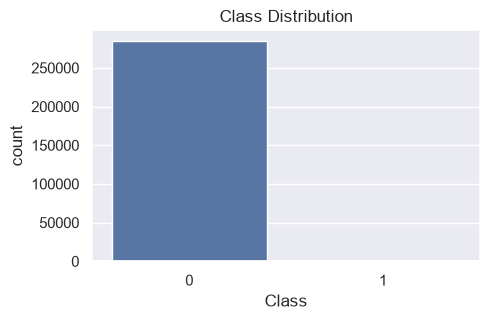

In [15]:
plt.figure(figsize=(5,3))
sns.countplot(x=df["Class"],data=df)
plt.title("Class Distribution")
plt.show()

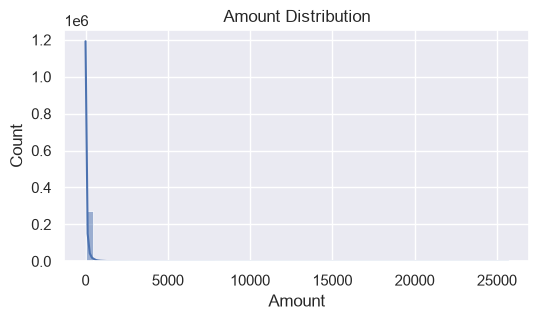

In [16]:
plt.figure(figsize=(6,3))
sns.histplot(df["Amount"],bins=60,kde=True)
plt.title("Amount Distribution")
plt.show()

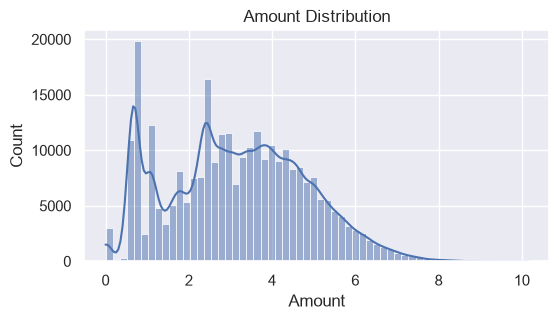

In [17]:
plt.figure(figsize=(6,3))
sns.histplot(np.log1p(df["Amount"]),bins=60,kde=True)
plt.title("Amount Distribution")
plt.show()

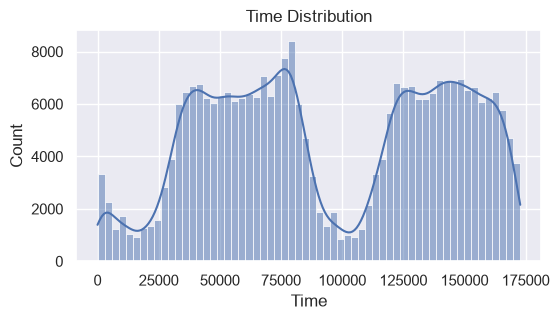

In [18]:
plt.figure(figsize=(6,3))
sns.histplot(df["Time"],bins=60,kde=True)
plt.title("Time Distribution")
plt.show()

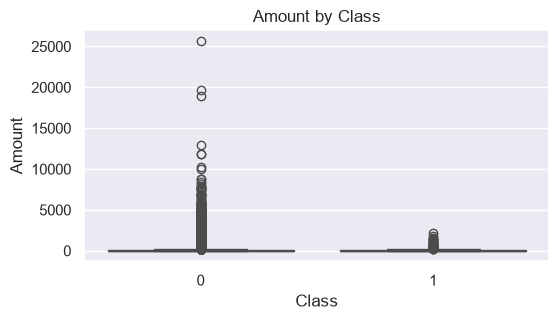

In [19]:
plt.figure(figsize=(6,3))
sns.boxplot(x="Class",y="Amount",data=df)
plt.title("Amount by Class")
plt.show()

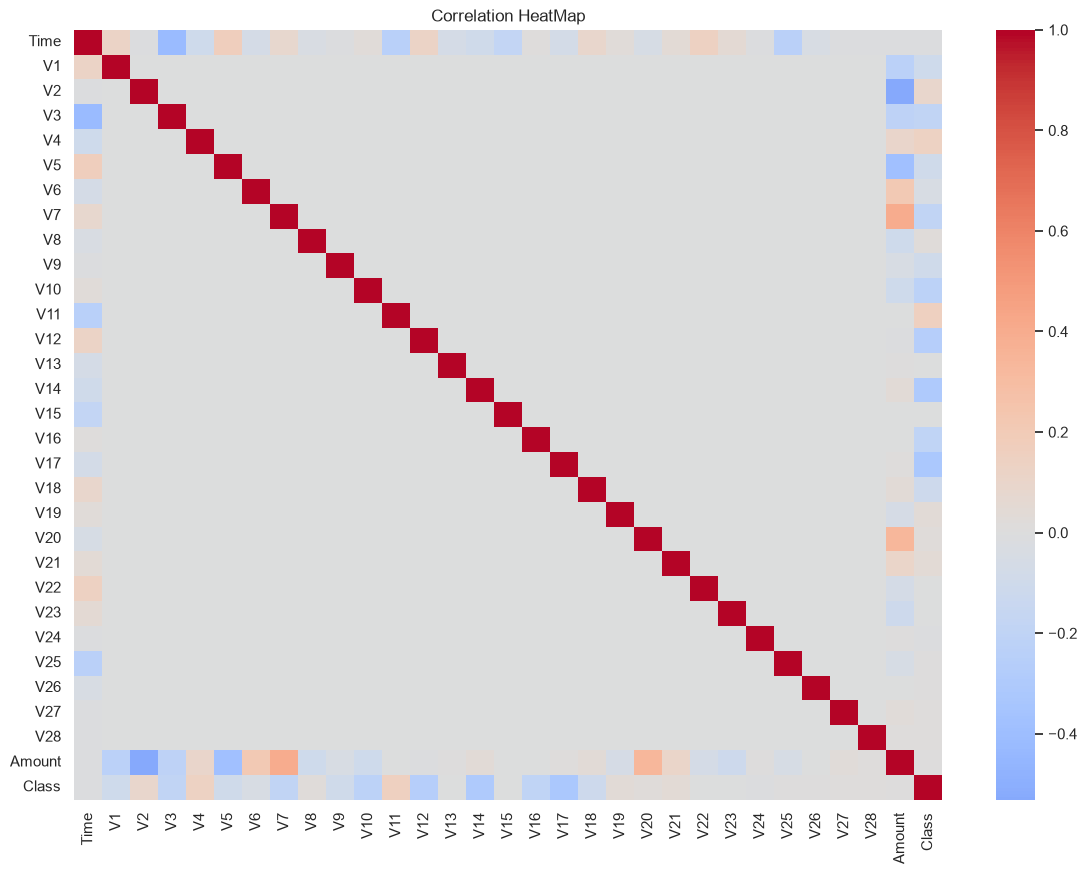

In [20]:
plt.figure(figsize=(14,10))
sns.heatmap(df.corr(numeric_only=True),cmap="coolwarm",center=0)
plt.title("Correlation HeatMap")
plt.show()

In [21]:
corr_target=df.corr(numeric_only=True)["Class"].sort_values(ascending=False)
corr_target.head(5),corr_target.tail(5)

(Class   1.000
 V11     0.155
 V4      0.133
 V2      0.091
 V21     0.040
 Name: Class, dtype: float64,
 V16   -0.197
 V10   -0.217
 V12   -0.261
 V14   -0.303
 V17   -0.326
 Name: Class, dtype: float64)

In [22]:
df["Amount_log"]=np.log1p(df["Amount"])

In [23]:
X=df.drop(columns=["Class","Amount"])
y=df["Class"]


In [24]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,stratify=y,random_state=42)


In [25]:
print('Dataset Shape',X.shape)
print("Training data shape",X_train.shape)
print("Test Data shape",X_test.shape)


Dataset Shape (284807, 30)
Training data shape (227845, 30)
Test Data shape (56962, 30)


In [26]:
base_pipeline=Pipeline(
    [
        ("model",DecisionTreeClassifier(random_state=42))
    ]
)

In [27]:
base_pipeline.fit(X_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](30,)","['Time','V1','V2',...,'V27','V28','Amount_log']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,30
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'


In [28]:
y_train_pred=base_pipeline.predict(X_train)
y_test_pred=base_pipeline.predict(X_test)



In [29]:
train_acc=round(accuracy_score(y_train,y_train_pred)*100,2)
test_acc=round(accuracy_score(y_test,y_test_pred)*100,2)
print(train_acc,test_acc)

100.0 99.91


In [30]:
print(classification_report(y_train,y_train_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00    227451
           1       1.00      1.00      1.00       394

    accuracy                           1.00    227845
   macro avg       1.00      1.00      1.00    227845
weighted avg       1.00      1.00      1.00    227845



In [31]:
print(classification_report(y_test,y_test_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.75      0.74      0.75        98

    accuracy                           1.00     56962
   macro avg       0.88      0.87      0.87     56962
weighted avg       1.00      1.00      1.00     56962



In [32]:
#accuracy score is not reliable becoz of class imbalance
#so we use precision auc
y_train_pred=base_pipeline.predict_proba(X_train)[:,1]
print("Average precision score",average_precision_score(y_train,y_train_pred))

Average precision score 1.0


In [33]:
y_test_pred=base_pipeline.predict_proba(X_test)[:,1]
print("Average precision score",average_precision_score(y_test,y_test_pred))

Average precision score 0.5610321985726947


In [34]:
k=5
cv=StratifiedKFold(n_splits=k,shuffle=True,random_state=42)


In [35]:
models={
    "dt_balance":Pipeline(
        [
          ("model",DecisionTreeClassifier(random_state=42,class_weight="balanced"))  
        ]
    ),
    "hgb_balance":Pipeline(
        [
            ("model",HistGradientBoostingClassifier(random_state=42,class_weight="balanced"))
        ]
    ),
    "rf_balance":Pipeline(
        [
            ("model",RandomForestClassifier(random_state=42,class_weight="balanced"))
        ]
    )
}
# model focuses on minority class in this case class 1 becoz we added class_weight="balanced"

In [37]:
for name,m in models.items():
    pr_auc_scores=[]
    for tr_idx,te_idx in cv.split(X_train,y_train):
        X_tr,X_te=X_train.iloc[tr_idx],X_train.iloc[te_idx]
        y_tr,y_te=y_train.iloc[tr_idx],y_train.iloc[te_idx]
        m.fit(X_tr,y_tr)
        pred_prob=m.predict_proba(X_te)[:,1]
        pr_auc_scores.append(average_precision_score(y_te,pred_prob))
    print("Model Nmae",name)
    print("PR-AUC values",pr_auc_scores)
    print("CV PR-auc Mean",round(float(np.mean(pr_auc_scores)),4))    

Model Nmae dt_balance
PR-AUC values [0.5007266812564823, 0.4830774702828517, 0.5797304220740939, 0.5880053883273093, 0.5312714890725482]
CV PR-auc Mean 0.5366
Model Nmae hgb_balance
PR-AUC values [0.7459748160308579, 0.7433183520877823, 0.7109857034613816, 0.7883890282421979, 0.7364096979770076]
CV PR-auc Mean 0.745
Model Nmae rf_balance
PR-AUC values [0.8531095932483966, 0.8095366810155712, 0.8262273784311938, 0.8843963969358334, 0.831471373528668]
CV PR-auc Mean 0.8409


In [38]:
#Hyper Parameter Tuning
rf_pipeline=Pipeline(
        [
            ("model",RandomForestClassifier(random_state=42,class_weight="balanced_subsample",n_jobs=-1))
        ]
    )
# n_jobs=-1 tells use all cores 

In [39]:
param_dist={
    "model__n_estimators":[200,300,500],
    "model__max_depth":[None,10,20,30],
    "model__min_samples_leaf":[1,5,10,20],
    "model__max_features":["sqrt","log2",0.5]
}

In [40]:
random_search=RandomizedSearchCV(
    estimator=rf_pipeline,
    param_distributions=param_dist,
    n_iter=10,
    scoring="average_precision",
    cv=cv,
    verbose=True
)

In [41]:
random_search.fit(X_train,y_train)

Fitting 5 folds for each of 10 candidates, totalling 50 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'model__max_depth': [None, 10, ...], 'model__max_features': ['sqrt', 'log2', ...], 'model__min_samples_leaf': [1, 5, ...], 'model__n_estimators': [200, 300, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'average_precision'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: int, default = 0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",True
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",10
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted e

In [42]:
print("Best CV PR-AUC",round(random_search.best_score_,4))
print("Best params",random_search.best_params_)


Best CV PR-AUC 0.848
Best params {'model__n_estimators': 500, 'model__min_samples_leaf': 1, 'model__max_features': 'sqrt', 'model__max_depth': None}


In [45]:
best_rf=Pipeline(
    [
        ("model",RandomForestClassifier(
            n_estimators=500,
            min_samples_leaf=1,
            max_features="log2",
            max_depth=30,
            random_state=42,
            n_jobs=-1,
            class_weight="balanced_subsample"
        ))
    ]
)

In [46]:
best_rf.fit(X_train,y_train)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](30,)","['Time','V1','V2',...,'V27','V28','Amount_log']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,30
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",500
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",30
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'log2'


In [48]:
y_train_pred=best_rf.predict(X_train)
train_acc=accuracy_score(y_train,y_train_pred)



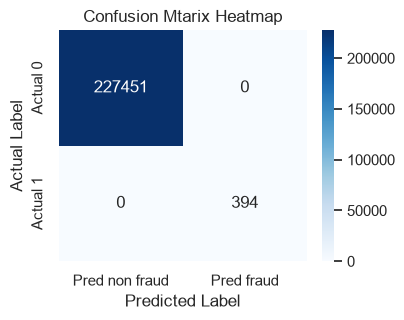

In [49]:
cm=confusion_matrix(y_train,y_train_pred)
plt.figure(figsize=(4,3))
sns.heatmap(cm,annot=True,fmt="d",cmap="Blues",
            xticklabels=["Pred non fraud","Pred fraud"],
            yticklabels=["Actual 0","Actual 1"])
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Mtarix Heatmap")
plt.show()

In [50]:
print("Classification Report")
print(classification_report(y_train,y_train_pred))

Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    227451
           1       1.00      1.00      1.00       394

    accuracy                           1.00    227845
   macro avg       1.00      1.00      1.00    227845
weighted avg       1.00      1.00      1.00    227845



In [51]:
print("Classification Report")
print(classification_report(y_test,y_test_pred))

Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.75      0.74      0.75        98

    accuracy                           1.00     56962
   macro avg       0.88      0.87      0.87     56962
weighted avg       1.00      1.00      1.00     56962



In [52]:
pred_prob=best_rf.predict_proba(X_test)[:,1]
print(round(average_precision_score(y_test,pred_prob),4))

0.8674


In [53]:
X_test.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount_log
263020,160760.000,-0.674,1.408,-1.111,-1.328,1.389,-1.308,1.886,-0.614,0.312,0.651,-0.858,-0.230,-0.200,0.266,-0.047,-0.741,-0.606,-0.393,-0.163,0.394,0.080,0.810,-0.224,0.708,-0.136,0.045,0.534,0.291,3.178
11378,19847.000,-2.830,-2.765,2.538,-1.075,2.843,-2.154,-1.796,-0.250,3.074,-1.000,1.851,-1.550,1.252,0.964,-0.481,-0.147,-0.209,1.059,0.397,-0.516,-0.296,0.109,-0.813,0.043,-0.028,-0.910,0.111,-0.512,2.553
147283,88326.000,-3.576,2.318,1.307,3.264,1.128,2.865,1.444,-0.719,1.874,7.398,2.081,-0.064,0.578,-2.430,1.506,-1.238,-0.390,-1.232,0.099,2.035,-1.060,0.017,-0.132,-1.484,-0.296,0.063,0.552,0.510,4.345
219439,141734.000,2.060,-0.015,-1.083,0.386,-0.024,-1.075,0.208,-0.338,0.455,0.048,-0.652,0.751,0.666,0.159,0.027,-0.171,-0.291,-1.009,0.097,-0.192,-0.282,-0.639,0.332,-0.068,-0.284,0.204,-0.064,-0.060,0.688
36939,38741.000,1.210,1.384,-1.344,1.764,0.662,-2.113,0.854,-0.476,-0.630,-1.580,1.463,0.209,0.735,-3.539,0.926,0.835,2.846,1.041,-1.045,0.009,-0.164,-0.328,-0.155,0.619,0.819,-0.331,0.047,0.105,0.916


In [57]:
y_test.head()

263020    0
11378     0
147283    0
219439    0
36939     0
Name: Class, dtype: int64

In [61]:
def predict(input):
    input_df=pd.DataFrame([input],columns=X_train.columns)
    prediction=best_rf.predict(input_df)
    if prediction[0]==0:
        print("Non Fraud")
    else:
        print("Fraud")

In [62]:
test1=X_test.loc[11378].tolist()

In [63]:
predict(test1)

Non Fraud


### Export Model Artifacts for Deployment


In [ ]:
import joblib

# Export trained fraud classification model
joblib.dump(best_rf, 'model.joblib')
print("Model successfully saved to model.joblib")
